# TUI Smart Destination Recommender

## Recommendation Engine Demonstration

This notebook demonstrates the end-to-end functionality of the AI-powered destination recommendation system.

### Objectives

- Load synthetic tourism datasets
- Generate personalized recommendations
- Evaluate sustainability metrics
- Analyze congestion impact
- Explain recommendation decisions
- Visualize recommendation results

### Project

TUI Smart Destination Recommender

Author: Octavio Alvarez

In [2]:
"""
=====================================================
Project Path Configuration
=====================================================

Purpose
-------
Configure notebook environment and enable imports
from the project source code.
"""

import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project Root:")
print(PROJECT_ROOT)

Project Root:
c:\Users\octavio.alvarez\Desktop\TUI-Smart-Destination-Recommender


In [3]:
"""
=====================================================
TUI Smart Destination Recommender
Recommendation Demo
=====================================================

Purpose
-------
Demonstrate the complete recommendation workflow.

Author
------
Octavio Alvarez
"""

import pandas as pd
import matplotlib.pyplot as plt

from src.data.data_loader import DataLoader

from src.recommendation.recommendation_engine import (
    RecommendationEngine
)

## Load Project Datasets

The recommendation engine relies on multiple datasets:

- Destinations
- Users
- Booking History
- Sustainability Scores
- Congestion Scores

This step validates that all datasets are available.

In [4]:
# --------------------------------------------------
# Load datasets
# --------------------------------------------------

destinations = DataLoader.load_destinations()

users = DataLoader.load_users()

bookings = DataLoader.load_bookings()

sustainability = (
    DataLoader.load_sustainability()
)

congestion = (
    DataLoader.load_congestion()
)

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [5]:
# --------------------------------------------------
# Dataset summary
# --------------------------------------------------

summary = pd.DataFrame(
    {
        "Dataset": [
            "Destinations",
            "Users",
            "Bookings",
            "Sustainability",
            "Congestion"
        ],
        "Records": [
            len(destinations),
            len(users),
            len(bookings),
            len(sustainability),
            len(congestion)
        ]
    }
)

summary

,Dataset,Records
0,Destinations,20
1,Users,100
2,Bookings,500
3,Sustainability,20
4,Congestion,240


## Destination Sample

Review a sample of available destinations.

In [6]:
destinations.head()

,destination_id,destination_name,region,destination_type,beach_score,culture_score,nature_score,nightlife_score,family_friendly_score,avg_price_per_day
0,D001,Mallorca,Balearic Islands,Beach,10,7,8,8,9,145
1,D002,Ibiza,Balearic Islands,Beach,10,6,6,10,5,190
2,D003,Menorca,Balearic Islands,Beach,9,6,9,4,10,135
3,D004,Tenerife,Canary Islands,Mixed,9,7,9,7,9,140
4,D005,Gran Canaria,Canary Islands,Mixed,9,6,8,7,8,135


## User Selection

Select a sample user for recommendation generation.

In [8]:
# --------------------------------------------------
# Select user
# --------------------------------------------------

sample_user_id = "U001"

user_profile = users[
    users["user_id"] == sample_user_id
]

user_profile

,user_id,country,age_group,budget_level,travel_style,sustainability_preference
0,U001,Germany,18-24,Low,Nature,Medium


## Initialize Recommendation Engine

In [9]:
# --------------------------------------------------
# Create recommendation engine
# --------------------------------------------------

engine = RecommendationEngine()

print(
    "Recommendation Engine initialized successfully."
)

Recommendation Engine initialized successfully.


## Generate Recommendations

Generate Top-5 destination recommendations for the selected user.

In [10]:
# --------------------------------------------------
# Generate recommendations
# --------------------------------------------------

recommendations = engine.recommend(
    user_id=sample_user_id,
    month=7,
    top_n=5
)

len(recommendations)

5

In [11]:
# --------------------------------------------------
# Convert results to DataFrame
# --------------------------------------------------

recommendations_df = pd.DataFrame(
    recommendations
)

recommendations_df

,destination_id,destination_name,final_score,preference_score,popularity_score,sustainability_score,congestion_score,confidence_score,explanations,recommendation_rank
0,D018,San Sebastian,70.96,80,56.73,84.8,65.0,73.98,[Strong match for your Nature travel preferenc...,1
1,D006,Lanzarote,68.55,100,70.13,73.6,85.0,85.76,[Strong match for your Nature travel preferenc...,2
2,D003,Menorca,68.48,90,97.40,80.9,95.0,90.40,[Strong match for your Nature travel preferenc...,3
3,D004,Tenerife,67.79,90,93.16,74.4,85.0,87.83,[Strong match for your Nature travel preferenc...,4
4,D019,Picos de Europa,67.51,100,47.76,82.4,85.0,80.81,[Strong match for your Nature travel preferenc...,5


## Recommendation Ranking

Top destinations ranked by final recommendation score.

In [12]:
recommendations_df[
    [
        "recommendation_rank",
        "destination_name",
        "final_score",
        "confidence_score"
    ]
]

,recommendation_rank,destination_name,final_score,confidence_score
0,1,San Sebastian,70.96,73.98
1,2,Lanzarote,68.55,85.76
2,3,Menorca,68.48,90.40
3,4,Tenerife,67.79,87.83
4,5,Picos de Europa,67.51,80.81


## Explainability Review

Review the explanation generated for each recommendation.

In [13]:
# --------------------------------------------------
# Display explanations
# --------------------------------------------------

for recommendation in recommendations:

    print(
        f"\nRecommendation #{recommendation['recommendation_rank']}"
    )

    print(
        recommendation["destination_name"]
    )

    print("-" * 50)

    for explanation in recommendation[
        "explanations"
    ]:

        print(
            f"• {explanation}"
        )


Recommendation #1
San Sebastian
--------------------------------------------------
• Strong match for your Nature travel preferences.
• Good sustainability performance.

Recommendation #2
Lanzarote
--------------------------------------------------
• Strong match for your Nature travel preferences.
• Good sustainability performance.
• Higher expected congestion during the selected period.
• Well-rated by previous travelers.

Recommendation #3
Menorca
--------------------------------------------------
• Strong match for your Nature travel preferences.
• Good sustainability performance.
• Higher expected congestion during the selected period.
• Popular among travelers with similar interests.

Recommendation #4
Tenerife
--------------------------------------------------
• Strong match for your Nature travel preferences.
• Good sustainability performance.
• Higher expected congestion during the selected period.
• Popular among travelers with similar interests.

Recommendation #5
Picos de 

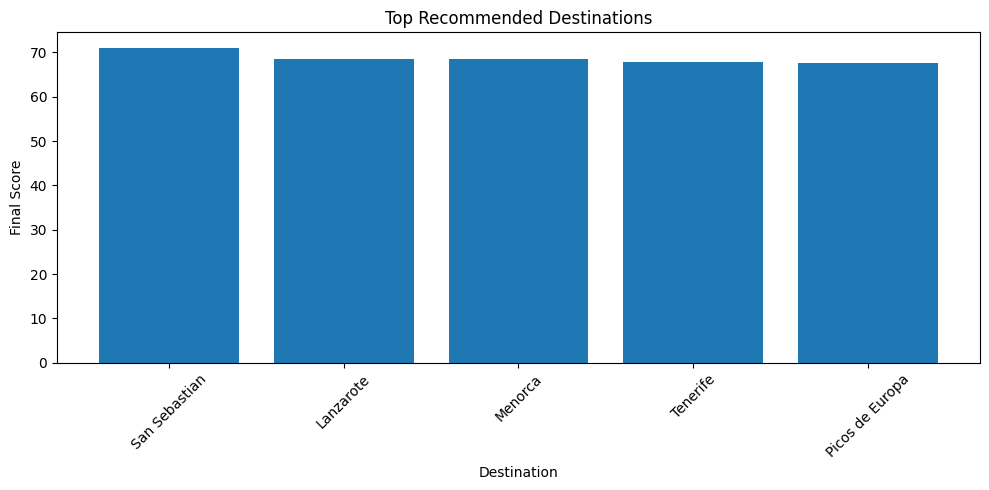

In [14]:
# --------------------------------------------------
# Recommendation scores
# --------------------------------------------------

plt.figure(figsize=(10, 5))

plt.bar(
    recommendations_df["destination_name"],
    recommendations_df["final_score"]
)

plt.title(
    "Top Recommended Destinations"
)

plt.xlabel(
    "Destination"
)

plt.ylabel(
    "Final Score"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

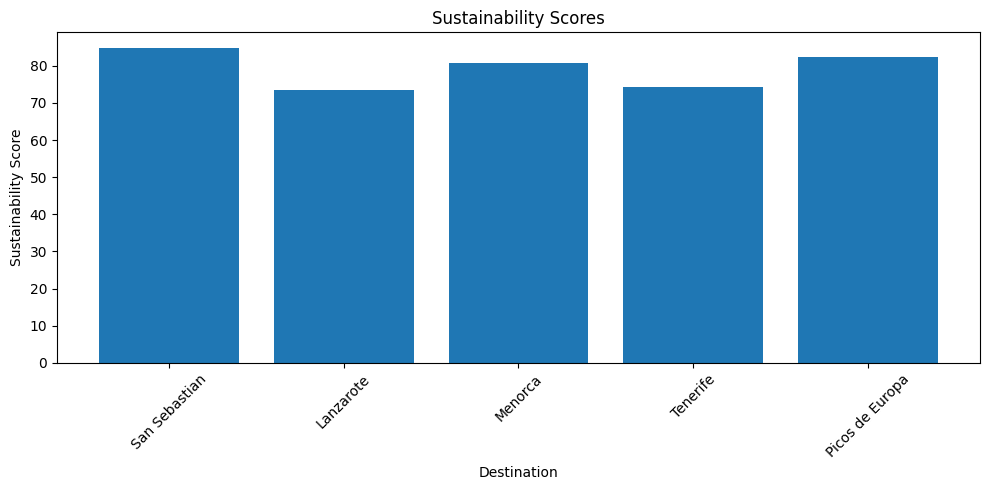

In [15]:
# --------------------------------------------------
# Sustainability analysis
# --------------------------------------------------

plt.figure(figsize=(10, 5))

plt.bar(
    recommendations_df["destination_name"],
    recommendations_df[
        "sustainability_score"
    ]
)

plt.title(
    "Sustainability Scores"
)

plt.xlabel(
    "Destination"
)

plt.ylabel(
    "Sustainability Score"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

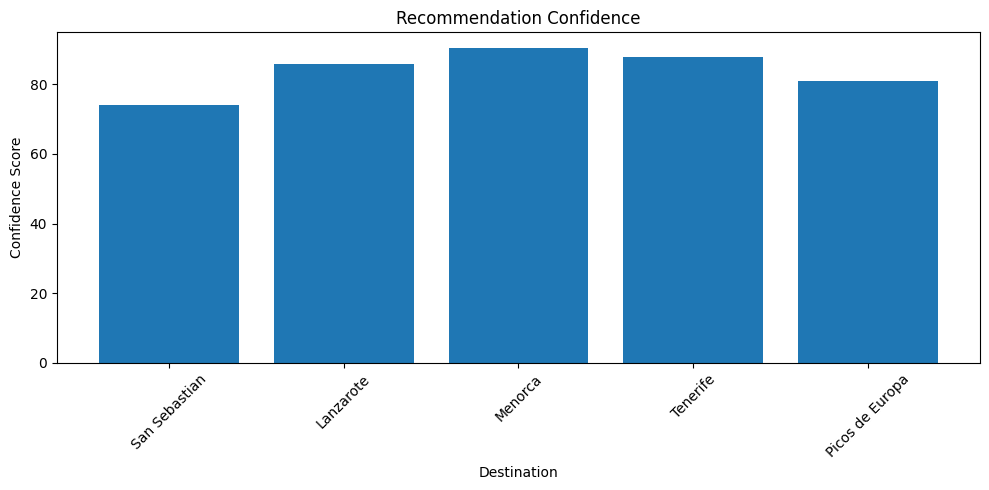

In [16]:
# --------------------------------------------------
# Confidence analysis
# --------------------------------------------------

plt.figure(figsize=(10, 5))

plt.bar(
    recommendations_df["destination_name"],
    recommendations_df[
        "confidence_score"
    ]
)

plt.title(
    "Recommendation Confidence"
)

plt.xlabel(
    "Destination"
)

plt.ylabel(
    "Confidence Score"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Conclusions

The recommendation engine successfully demonstrates:

- Personalized destination recommendations
- Sustainability-aware scoring
- Congestion-aware adjustments
- Popularity-based ranking influence
- Explainable AI recommendations
- Recommendation confidence estimation

The system is now ready for integration into the Streamlit Dashboard MVP.